# Exploratory Data Analysis
### IndicNews AI — Hindi News Analysis, Retrieval & Recommendation System

In [ ]:
import sys
sys.path.append("..")

import pandas as pd
import matplotlib.pyplot as plt

from data_utils import load_dataset

pd.set_option("display.max_colwidth", 120)
%matplotlib inline

## 1. Load the dataset

`load_dataset()` loads the real CSV from `dataset/hindi_news_dataset.csv`
and derives two convenience columns we'll rely on throughout the project:

- **`category_list`** - the raw `News Categories` column parsed from its
  stringified-list form (e.g. `"['politics', 'national']"`) into an actual
  Python list of lowercase tags.
- **`core_categories`** - that tag list filtered down to just the
  categories the classifier is trained on (Sports / Politics / Business /
  Technology / Entertainment / National), keeping **all** matching tags
  per row rather than picking one , a row genuinely can be both `sports`
  and `national` at once. Rows with no core tag get `["other"]`.

In [ ]:
df = load_dataset()
df.head(3)

[data_utils] Loaded dataset: ../../dataset/hindi_news_dataset.csv
[data_utils] Shape: (185512, 7)
[data_utils] Unparseable dates: 0 (0.00%)
[data_utils] core_categories tag counts (rows can have >1 tag):
core_categories
national         59002
other            34124
business         28014
politics         27828
entertainment    26212
technology       25048
sports           24920
Name: count, dtype: int64
[data_utils] labels per row:
core_categories
1    146808
2     37805
3       866
4        33
Name: count, dtype: int64


,Headline,Content,News Categories,Date,category_list,core_categories,parsed_date
0,कांग्रेस नेता बलजिंदर सिंह की पंजाब में घर के अंदर गोली मारकर की गई हत्या,कांग्रेस नेता बलजिंदर सिंह की सोमवार को पंजाब के मोगा में उनके घर में गोली मारकर हत्या कर दी गई। ऑनलाइन सामने आए सीस...,['national'],19-09-2023,[national],[national],2023-09-19
1,केंद्रीय मंत्री बोले- महिला आरक्षण लाने का साहस मोदी सरकार में था; बाद में डिलीट किया पोस्ट,केंद्रीय मंत्री प्रह्लाद पटेल ने लोकसभा और विधानसभाओं में महिला आरक्षण को लेकर 'X' पर पोस्ट किया कि यह मांग पूरी करन...,"['politics', 'national']",19-09-2023,"[politics, national]","[politics, national]",2023-09-19
2,ओपीएस लागू करने से अस्थिर हो सकती है राज्यों की वित्तीय स्थिति: आरबीआई अधिकारी,आरबीआई के 5 अधिकारियों ने एक लेख में लिखा है कि राज्यों द्वारा पुरानी पेंशन योजना (ओपीएस) लागू करना पीछे ले जाने वाल...,"['business', 'national']",19-09-2023,"[business, national]","[business, national]",2023-09-19


## 2. Shape, columns, and data quality checks

`News Categories` is a stringified list of 1–5 tags per article, mixing broad sections
(`national`, `world`, `business`, `politics`, `entertainment`,
`technology`, `sports`, `miscellaneous`) with narrow event hashtags like
`लोकसभा_चुनाव_2024` or `आईपीएल_2024`.

In [ ]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nMissing values per column:")
print(df[["Headline", "Content", "News Categories", "Date"]].isnull().sum())

Shape: (185512, 7)

Columns: ['Headline', 'Content', 'News Categories', 'Date', 'category_list', 'core_categories', 'parsed_date']

Missing values per column:
Headline           0
Content            0
News Categories    0
Date               0
dtype: int64


### 2.1 Duplicate rows — an important finding

The Inshorts homepage was scraped repeatedly over time, and the same
article stays on the front page (and therefore gets re-scraped) for
several consecutive days. That means the **same article appears multiple
times under different dates**, it's how the
scrape was collected, but it has a big practical consequence: if we split
train/test **before deduplicating**, near-identical rows leak across the
split and inflate every metric.


In [ ]:
n_total = len(df)
n_unique_headline = df["Headline"].nunique()
n_unique_article = df.drop_duplicates(subset=["Headline", "Content"]).shape[0]

print(f"Total rows:                         {n_total:,}")
print(f"Unique headlines:                   {n_unique_headline:,}")
print(f"Unique (Headline + Content) rows:   {n_unique_article:,}")
print(f"Average re-scrape count per article: {n_total / n_unique_article:.1f}x")

Total rows:                         185,512
Unique headlines:                   34,748
Unique (Headline + Content) rows:   34,826
Average re-scrape count per article: 5.3x


## 3. Category labels: kept multi-label, not collapsed to one

Distribution of the number of raw tags per row:

In [ ]:
df["category_list"].apply(len).value_counts().sort_index()

category_list
1    105137
2     71024
3      9062
4       281
5         8
Name: count, dtype: int64

`derive_core_categories()` (in `data_utils.py`) filters each row's tag
list down to just the categories the classifier is trained on —
`sports`, `politics`, `business`, `technology`, `entertainment`,
`national` — but deliberately **keeps every matching tag**, since a row
is often legitimately more than one of these at once (e.g. a story can
be both `sports` and `national`). Collapsing that down to a single
"first match wins" label would silently throw away real information, so
`core_categories` is a **list column**; rows with no core tag get
`["other"]`.

In [ ]:
tag_counts = df["core_categories"].explode().value_counts()
tag_counts

core_categories
national         59002
other            34124
business         28014
politics         27828
entertainment    26212
technology       25048
sports           24920
Name: count, dtype: int64

In [21]:
df["core_categories"].apply(len).value_counts().sort_index()

core_categories
1    146808
2     37805
3       866
4        33
Name: count, dtype: int64

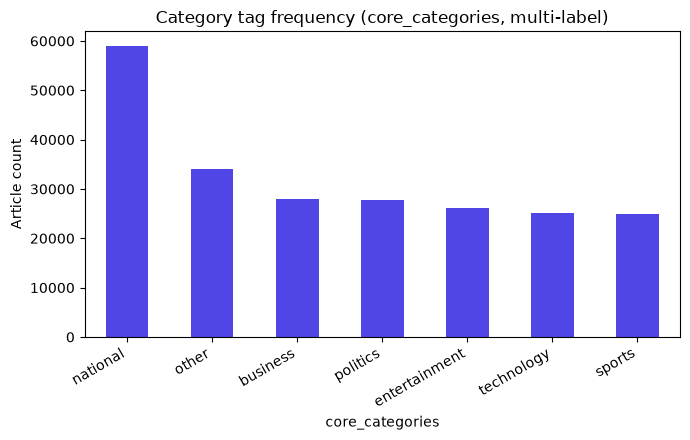

In [22]:
plt.figure(figsize=(7, 4.5))
tag_counts.plot(kind="bar", color="#4f46e5")
plt.title("Category tag frequency (core_categories, multi-label)")
plt.ylabel("Article count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Observation:** `national` is the most frequent tag (~32% of rows carry
it, often alongside another core tag), `other` next (~18%), and the
remaining five core categories are reasonably balanced with each other
(13–15% each). Because bars can overlap (multi-label), these don't sum to
100% of rows — 37,805 rows carry 2 tags and 899 carry 3–4. 

### 3.1 Deduplicated category distribution

Same breakdown, but counting each unique article once 

In [ ]:
uniq = df.drop_duplicates(subset=["Headline", "Content"])
uniq["core_categories"].explode().value_counts()

core_categories
national         14761
sports            5591
entertainment     5091
politics          5040
other             4535
business          3596
technology        1702
Name: count, dtype: int64

Technology drops noticeably relative to the others once duplicates are
removed (fewer distinct tech articles were re-scraped as often) 

## 4. Text length profiling

Word counts for headlines and article bodies:

In [ ]:
df["headline_len_words"] = df["Headline"].str.split().apply(len)
df["content_len_words"] = df["Content"].str.split().apply(len)
df[["headline_len_words", "content_len_words"]].describe()

,headline_len_words,content_len_words
count,185512.000000,185512.000000
mean,14.937163,59.118639
std,2.922439,1.657601
min,3.000000,13.000000
25%,13.000000,59.000000
50%,15.000000,60.000000
75%,17.000000,60.000000
max,23.000000,61.000000


**Observation:** article content clusters tightly around ~59–60 words
with very low spread (std ≈ 1.7). This matches Inshorts' well-known
editorial format of summarizing every story in "60 words" 

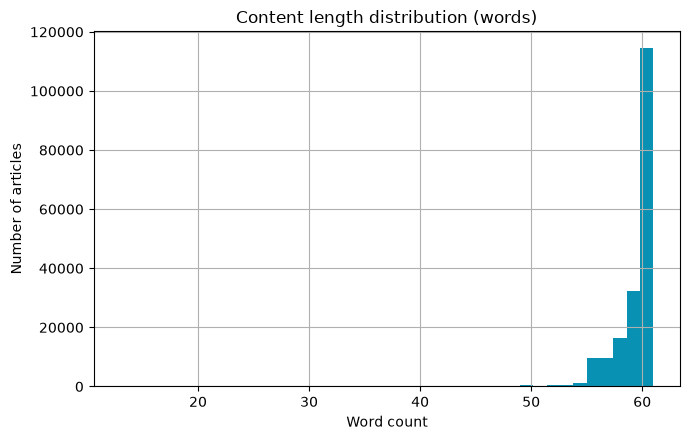

In [23]:
plt.figure(figsize=(7, 4.5))
df["content_len_words"].clip(upper=200).hist(bins=40, color="#0891b2")
plt.title("Content length distribution (words)")
plt.xlabel("Word count")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

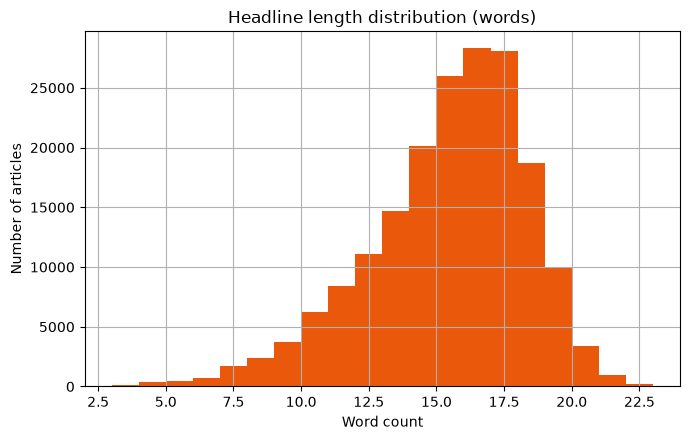

In [ ]:
plt.figure(figsize=(7, 4.5))
df["headline_len_words"].hist(bins=20, color="#ea580c")
plt.title("Headline length distribution (words)")
plt.xlabel("Word count")
plt.ylabel("Number of articles")
plt.tight_layout()
plt.show()

## 5. Date coverage

The raw `Date` column mixes `DD-MM-YYYY` and `YYYY-MM-DD` formats across
rows. `data_utils.parse_dates()` handles both and reports 0 unparseable
rows on the real file 

In [ ]:
print("Date range:", df["parsed_date"].min().date(), "to", df["parsed_date"].max().date())
print("Days covered:", df["parsed_date"].dt.date.nunique())

Date range: 2023-09-19 to 2024-08-26
Days covered: 83


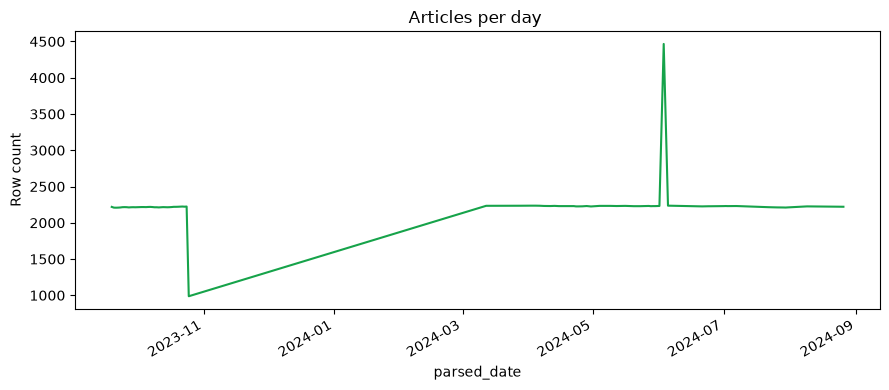

In [24]:
daily = df["parsed_date"].value_counts().sort_index()
plt.figure(figsize=(9, 4))
daily.plot(color="#16a34a")
plt.title("Articles per day ")
plt.ylabel("Row count")
plt.tight_layout()
plt.show()

The roughly constant ~800–900 rows/day reflects a fixed-size scrape of
"current front page" each day (hence the heavy re-scrape duplication
noted in §2.1), not a change in real news volume.

## 6. Sample rows per category

A quick qualitative sanity check — one example per core category:

In [20]:
for cat in ["sports", "politics", "business", "technology", "entertainment", "national", "other"]:
    row = df[df["core_categories"].apply(lambda tags: cat in tags)].iloc[0]
    print(f"--- {cat.upper()} ---")
    print("Headline:", row["Headline"])
    print("Content :", row["Content"][:160], "...")
    print()

--- SPORTS ---
Headline: पूर्व भारतीय कप्तान सौरव गांगुली पश्चिम बंगाल में लगाएंगे स्टील फैक्ट्री
Content : भारतीय क्रिकेट टीम के पूर्व कप्तान सौरव गांगुली पश्चिम मेदिनीपुर (पश्चिम बंगाल) ज़िले में एक स्टील फैक्ट्री शुरू करने वाले हैं। उन्होंने कहा, "बहुत से लोग मानते ...

--- POLITICS ---
Headline: केंद्रीय मंत्री बोले- महिला आरक्षण लाने का साहस मोदी सरकार में था; बाद में डिलीट किया पोस्ट
Content : केंद्रीय मंत्री प्रह्लाद पटेल ने लोकसभा और विधानसभाओं में महिला आरक्षण को लेकर 'X' पर पोस्ट किया कि यह मांग पूरी करने का नैतिक साहस प्रधानमंत्री नरेंद्र मोदी के ...

--- BUSINESS ---
Headline: ओपीएस लागू करने से अस्थिर हो सकती है राज्यों की वित्तीय स्थिति: आरबीआई अधिकारी
Content : आरबीआई के 5 अधिकारियों ने एक लेख में लिखा है कि राज्यों द्वारा पुरानी पेंशन योजना (ओपीएस) लागू करना पीछे ले जाने वाला कदम है। अधिकारियों के मुताबिक, इससे राज्यो ...

--- TECHNOLOGY ---
Headline: 'टाइम' के मुताबिक दुनिया की 10 सबसे बेहतरीन कंपनियां कौनसी हैं?
Content : 'टाइम' मैगज़ीन ने माइक्रोसॉफ्ट को दुनिया की 10

## 7. Summary & decisions carried into later modules

| Finding | Decision for later modules |
|---|---|
| `News Categories` is a multi-label stringified list, not a single label | `derive_core_categories()` keeps ALL matching core tags as a list — Module 6 trains a **multi-label** classifier, not single-label |
| Dates mix two formats | `parse_dates()` handles both; use `parsed_date` everywhere downstream |
| ~5.3× duplicate rows from repeated daily scraping | Deduplicate on `(Headline, Content)` before train/test split, TF-IDF fitting, and similarity search, to avoid leakage |
| Content length is tightly clustered (~59–60 words) | No aggressive truncation needed in feature engineering; summarization framed as optional/for longer pasted articles |
| `national` is the most frequent tag (~32%), `other` next (~18%) | Decide in Module 6 whether to train on all 6 core classes or exclude `other`; watch `national` co-occurring heavily with other tags |
| ~20% of rows carry 2+ core tags | Confirms multi-label framing is necessary — a single-label model would misrepresent these rows |
| `technology` share drops most after deduplication | Watch for class imbalance; consider class weighting in Module 6 |
